# 05 - Sentiment vs. Next-Day Stock Returns

Notebook 04 evaluated FinBERT headline-by-headline. This notebook aggregates
those predictions into a **daily sentiment signal** per trading day and tests
whether it correlates with next-day returns across five tickers (AAPL, MSFT,
GOOGL, AMZN, TSLA).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")

OUT = Path.cwd().parent / "outputs"
daily_sentiment = pd.read_csv(OUT / "daily_sentiment.csv")
stock_df        = pd.read_csv(OUT / "stock_data.csv", parse_dates=["date"])

print(f"Daily sentiment rows: {len(daily_sentiment)}")
print(f"Stock data rows: {len(stock_df)}  |  tickers: {sorted(stock_df['ticker'].unique())}")
daily_sentiment.head()

Daily sentiment rows: 503
Stock data rows: 2500  |  tickers: ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'TSLA']


,day_idx,headline_count,mean_score,positive_pct,negative_pct,neutral_pct
0,0,11,0.223359,45.454545,18.181818,36.363636
1,1,11,0.052534,27.272727,18.181818,54.545455
2,2,11,0.294586,27.272727,0.000000,72.727273
3,3,11,-0.226139,9.090909,27.272727,63.636364
4,4,11,0.409275,54.545455,0.000000,45.454545


## Methodology caveat

Financial PhraseBank sentences have **no real publication dates**. To build
`daily_sentiment.csv`, the 5,842 headlines were spread evenly across ~503
trading days as a placeholder alignment (see `src/correlation.py`,
`aggregate_daily_sentiment`). There is **no genuine temporal relationship**
between "day 47's sentiment score" and "day 47's actual news" - day 47 is
just "headlines 547 through 558 in the CSV", whatever those happen to be.

This means: **any correlation found below is not evidence about real
markets.** What this notebook *does* validate is the pipeline - daily
aggregation, alignment with next-day returns, Pearson/Spearman testing with
correct p-values, and direction-accuracy scoring.

## Correlation per ticker

For each ticker: align `mean_score` (day *t* sentiment) with
`next_day_return` (day *t+1* return), drop any NaNs, and compute Pearson,
Spearman, and direction accuracy (does `sign(sentiment) == sign(return)`?).

In [2]:
rows = []
ticker_data = {}

for ticker in sorted(stock_df["ticker"].unique()):
    price_df = stock_df[stock_df["ticker"] == ticker].reset_index(drop=True)
    n = min(len(daily_sentiment), len(price_df))

    x = daily_sentiment["mean_score"].values[:n]
    y = price_df["next_day_return"].values[:n]
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    pearson_r, pearson_p   = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    dir_acc = (np.sign(x) == np.sign(y)).mean()

    ticker_data[ticker] = (x, y)
    rows.append({
        "ticker": ticker, "n_days": mask.sum(),
        "pearson_r": pearson_r, "pearson_p": pearson_p,
        "spearman_r": spearman_r, "spearman_p": spearman_p,
        "direction_acc": dir_acc,
    })

results_df = pd.DataFrame(rows).set_index("ticker")
results_df.round(4)

,n_days,pearson_r,pearson_p,spearman_r,spearman_p,direction_acc
ticker,,,,,,
AAPL,500,0.0064,0.8864,0.0134,0.7649,0.502
AMZN,500,-0.0329,0.4623,-0.0067,0.8813,0.508
GOOGL,500,-0.0455,0.3098,-0.0332,0.4584,0.500
MSFT,500,-0.0079,0.8593,0.0062,0.8892,0.502
TSLA,500,-0.0251,0.5749,-0.0176,0.6946,0.502


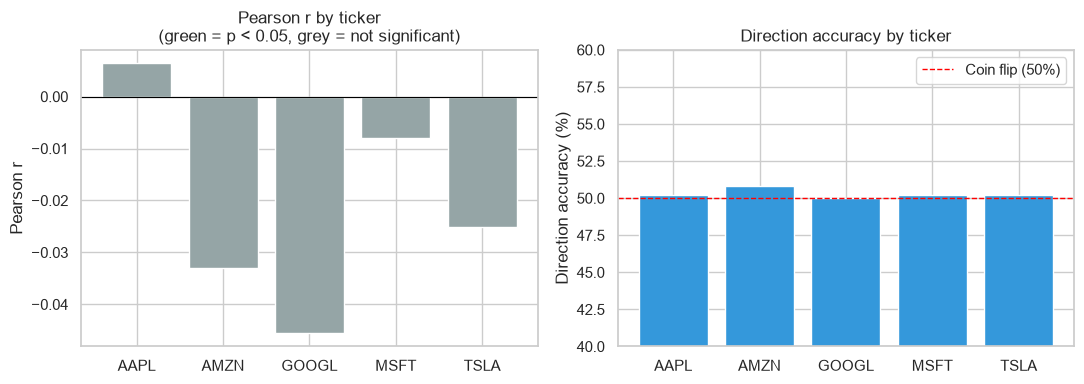


Tickers with p < 0.05: 0 / 5
Direction accuracy range: 50.0% - 50.8%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pearson r with significance threshold
colors = ["#2ecc71" if p < 0.05 else "#95a5a6" for p in results_df["pearson_p"]]
axes[0].bar(results_df.index, results_df["pearson_r"], color=colors)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Pearson r by ticker\n(green = p < 0.05, grey = not significant)")
axes[0].set_ylabel("Pearson r")

# Direction accuracy vs. 50% coin flip
axes[1].bar(results_df.index, results_df["direction_acc"] * 100, color="#3498db")
axes[1].axhline(50, color="red", ls="--", lw=1, label="Coin flip (50%)")
axes[1].set_title("Direction accuracy by ticker")
axes[1].set_ylabel("Direction accuracy (%)")
axes[1].set_ylim(40, 60)
axes[1].legend()

plt.tight_layout()
plt.show()

n_significant = (results_df["pearson_p"] < 0.05).sum()
print(f"\nTickers with p < 0.05: {n_significant} / {len(results_df)}")
print(f"Direction accuracy range: {results_df['direction_acc'].min()*100:.1f}% - "
      f"{results_df['direction_acc'].max()*100:.1f}%")

## A closer look: scatter + regression for one ticker

Even a "null" result is worth visualising - what does "no relationship"
actually look like as a scatter plot, versus what a real relationship would
look like?

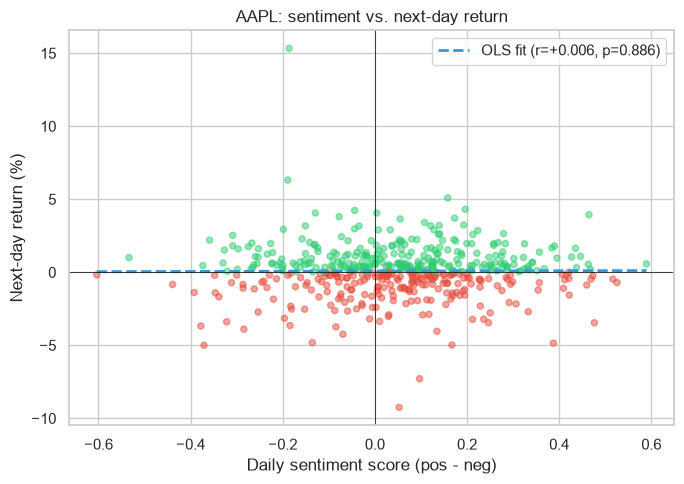

In [4]:
ticker = results_df["n_days"].idxmax()  # pick any ticker with full data
x, y = ticker_data[ticker]

fig, ax = plt.subplots(figsize=(7, 5))
point_colors = ["#2ecc71" if yi > 0 else "#e74c3c" for yi in y]
ax.scatter(x, y, c=point_colors, alpha=0.5, s=20)

slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, "--", color="#3498db", lw=2,
        label=f"OLS fit (r={r:+.3f}, p={p:.3f})")

ax.axhline(0, color="black", lw=0.5)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Daily sentiment score (pos - neg)")
ax.set_ylabel("Next-day return (%)")
ax.set_title(f"{ticker}: sentiment vs. next-day return")
ax.legend()
plt.tight_layout()
plt.show()

## What would make this real?

The pipeline above - aggregation, Pearson/Spearman, direction accuracy,
visualisation - is correct and complete. The only missing input is **dated
headlines**. A real version would need:

1. **A news source with real timestamps** - e.g. Alpha Vantage's News
   Sentiment endpoint, NewsAPI, or RSS feeds from Reuters/Bloomberg, each
   headline tagged with its actual publish datetime.
2. **Ticker-specific headline filtering** - Financial PhraseBank headlines
   aren't about any specific company in `DEFAULT_TICKERS`; a real version
   needs headlines that actually mention AAPL/MSFT/etc. (or are tagged with
   that ticker by the news API).
3. **Re-running this exact notebook** - `aggregate_daily_sentiment` would
   group by the headline's real date instead of evenly distributing rows,
   and every cell from here on works unchanged.

## Summary - across all five notebooks

01 found the class imbalance and confirmed financial signal words correlate
with sentiment. 02 tested that assumption against a naive pipeline and found
the real benefit is negation handling, plus two preprocessing gaps. 03
reproduced the classical baselines, ran a negation ablation. 04 showed
FinBERT's zero-shot ~8-point gain is concentrated in the negative class, with
genuinely uncertain (not confidently wrong) failure modes. 05 built and
validated a complete correlation pipeline.